Features shape: (7043, 76)
Target shape: (7043,)
Churn rate: 26.54%
Train set: 5634 samples
Test set: 1409 samples
Train churn rate: 26.54%
Test churn rate: 26.54%
Training Logistic Regression...
Logistic Regression - AUC: 0.8466

Training Random Forest...
Random Forest - AUC: 0.8388

Training XGBoost...
XGBoost - AUC: 0.8369

Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3364
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warni

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
logistic_regression,0.738112,0.504259,0.791444,0.616025,0.846589
neural_network,0.804116,0.676259,0.502674,0.576687,0.845305
ensemble,0.779986,0.572727,0.673797,0.619165,0.840266
random_forest,0.768630,0.549180,0.716578,0.621810,0.838775
xgboost,0.789212,0.623794,0.518717,0.566423,0.836885
lightgbm,0.751597,0.522472,0.745989,0.614537,0.835979


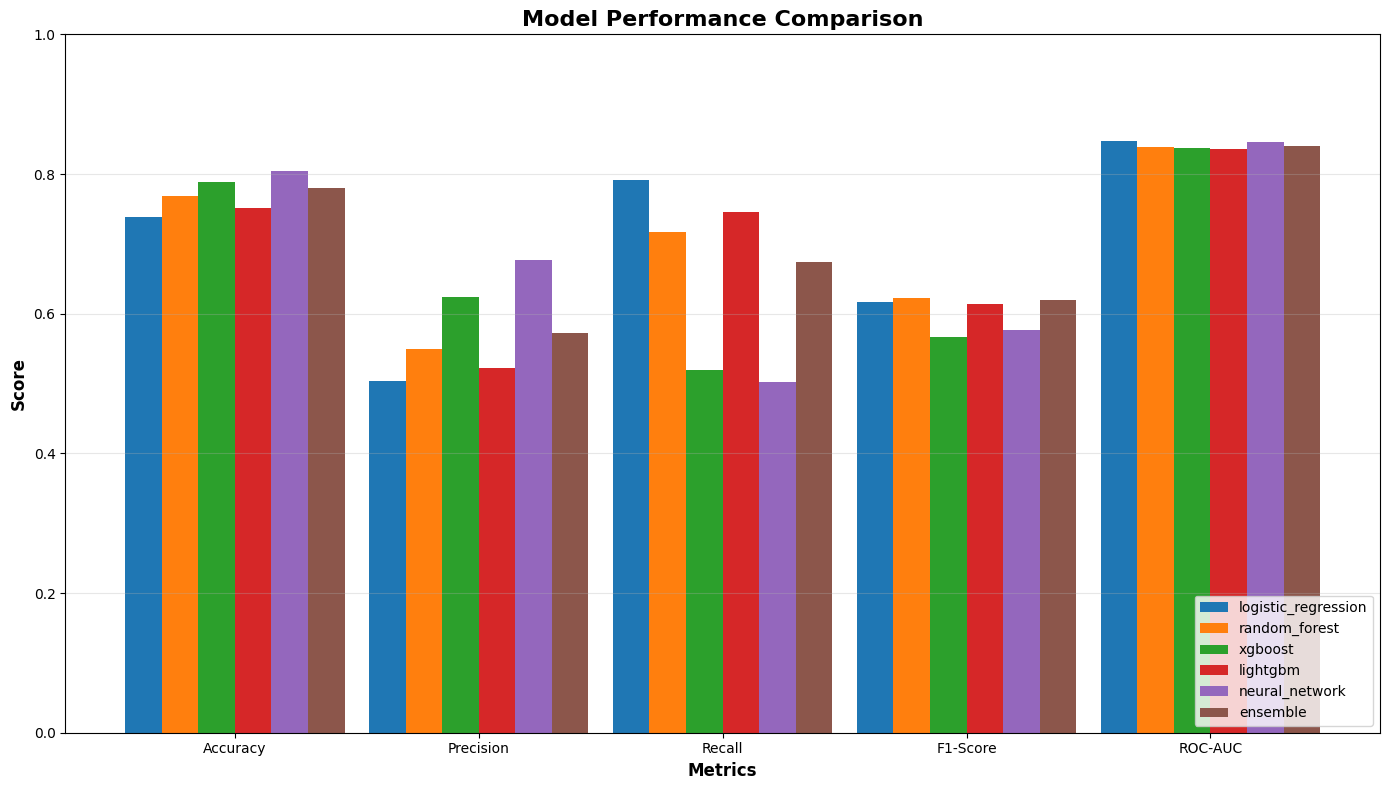


BEST MODEL: LOGISTIC_REGRESSION
ROC-AUC: 0.8466
Accuracy: 0.7381
Precision: 0.5043
Recall: 0.7914
F1-Score: 0.6160

CLASSIFICATION REPORT - LOGISTIC_REGRESSION
              precision    recall  f1-score   support

   Not Churn       0.91      0.72      0.80      1035
       Churn       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



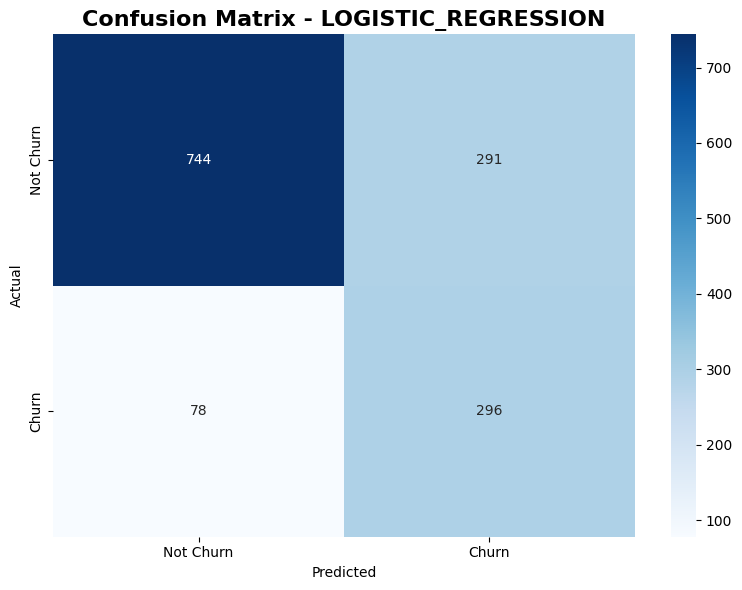

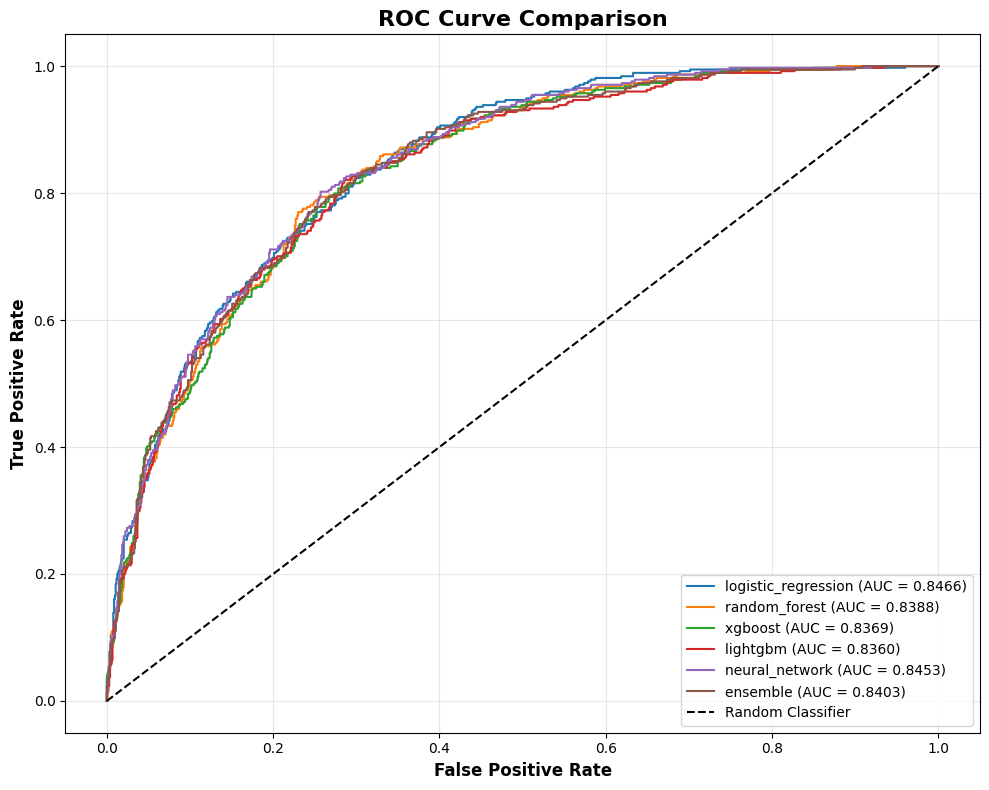


✅ Best model saved to ../models/best_model_logistic_regression.pkl
✅ All models saved successfully!

MODEL TRAINING COMPLETED SUCCESSFULLY!

Best Model: LOGISTIC_REGRESSION
Best ROC-AUC: 0.8466

All models and results saved to ../models/


In [2]:
# %% [markdown]
# # Telco Churn AI System - Model Training & Comparison
# 
# **Objective:** Train and compare multiple ML models for churn prediction
# 
# **Models to train:**
# 1. Logistic Regression
# 2. Random Forest
# 3. XGBoost
# 4. LightGBM
# 5. Neural Network (PyTorch)
# 6. Ensemble (Voting Classifier)

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)
torch.manual_seed(42)

# %%
# Load features and target
X = pd.read_csv('../data/processed/features_scaled.csv')
y = pd.read_csv('../data/processed/target.csv')['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Churn rate: {y.mean():.2%}")

# %%
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

# %%
# ==================== MODEL TRAINING ====================

models = {}
results = {}

# %%
# 1. LOGISTIC REGRESSION

print("Training Logistic Regression...")
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test)
y_pred_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# Metrics
results['logistic_regression'] = {
    'model': log_reg,
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_lr)
}

print(f"Logistic Regression - AUC: {results['logistic_regression']['roc_auc']:.4f}")

# %%
# 2. RANDOM FOREST

print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# Metrics
results['random_forest'] = {
    'model': rf,
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_rf)
}

print(f"Random Forest - AUC: {results['random_forest']['roc_auc']:.4f}")

# %%
# 3. XGBOOST

print("\nTraining XGBoost...")
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# Metrics
results['xgboost'] = {
    'model': xgb,
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb),
    'recall': recall_score(y_test, y_pred_xgb),
    'f1': f1_score(y_test, y_pred_xgb),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_xgb)
}

print(f"XGBoost - AUC: {results['xgboost']['roc_auc']:.4f}")

# %%
# 4. LIGHTGBM

print("\nTraining LightGBM...")
lgbm = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
lgbm.fit(X_train, y_train)

# Predictions
y_pred_lgbm = lgbm.predict(X_test)
y_pred_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

# Metrics
results['lightgbm'] = {
    'model': lgbm,
    'accuracy': accuracy_score(y_test, y_pred_lgbm),
    'precision': precision_score(y_test, y_pred_lgbm),
    'recall': recall_score(y_test, y_pred_lgbm),
    'f1': f1_score(y_test, y_pred_lgbm),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_lgbm)
}

print(f"LightGBM - AUC: {results['lightgbm']['roc_auc']:.4f}")

# %%
# 5. NEURAL NETWORK (PyTorch)

print("\nTraining Neural Network...")

class ChurnNN(nn.Module):
    def __init__(self, input_dim):
        super(ChurnNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize model
input_dim = X_train.shape[1]
nn_model = ChurnNN(input_dim)
criterion = nn.BCELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Training loop
best_val_loss = float('inf')
patience_counter = 0
epochs = 50

for epoch in range(epochs):
    nn_model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = nn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    
    # Early stopping check
    if avg_loss < best_val_loss:
        best_val_loss = avg_loss
        patience_counter = 0
        torch.save(nn_model.state_dict(), '../models/best_nn_model.pth')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# Load best model
nn_model.load_state_dict(torch.load('../models/best_nn_model.pth'))

# Predictions
nn_model.eval()
with torch.no_grad():
    y_pred_proba_nn = nn_model(X_test_tensor).numpy().flatten()
    y_pred_nn = (y_pred_proba_nn >= 0.5).astype(int)

# Metrics
results['neural_network'] = {
    'model': nn_model,
    'accuracy': accuracy_score(y_test, y_pred_nn),
    'precision': precision_score(y_test, y_pred_nn),
    'recall': recall_score(y_test, y_pred_nn),
    'f1': f1_score(y_test, y_pred_nn),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_nn)
}

print(f"Neural Network - AUC: {results['neural_network']['roc_auc']:.4f}")

# %%
# 6. ENSEMBLE (Voting Classifier)

print("\nTraining Ensemble Model...")

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm)
    ],
    voting='soft',
    weights=[1, 1, 1]
)
ensemble.fit(X_train, y_train)

# Predictions
y_pred_ensemble = ensemble.predict(X_test)
y_pred_proba_ensemble = ensemble.predict_proba(X_test)[:, 1]

# Metrics
results['ensemble'] = {
    'model': ensemble,
    'accuracy': accuracy_score(y_test, y_pred_ensemble),
    'precision': precision_score(y_test, y_pred_ensemble),
    'recall': recall_score(y_test, y_pred_ensemble),
    'f1': f1_score(y_test, y_pred_ensemble),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_ensemble)
}

print(f"Ensemble - AUC: {results['ensemble']['roc_auc']:.4f}")

# %%
# ==================== MODEL COMPARISON ====================

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    model: {
        'Accuracy': results[model]['accuracy'],
        'Precision': results[model]['precision'],
        'Recall': results[model]['recall'],
        'F1-Score': results[model]['f1'],
        'ROC-AUC': results[model]['roc_auc']
    }
    for model in results.keys()
}).T

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
display(comparison_df.sort_values('ROC-AUC', ascending=False))

# %%
# Visualization: Model comparison
plt.figure(figsize=(14, 8))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.15

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, (model, color) in enumerate(zip(comparison_df.index, colors)):
    plt.bar(x + i*width, comparison_df.loc[model, metrics].values, width, label=model, color=color)

plt.xlabel('Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.xticks(x + 2.5*width, metrics)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
# Select best model
best_model_name = comparison_df['ROC-AUC'].idxmax()
best_model = results[best_model_name]['model']

print("\n" + "=" * 80)
print(f"BEST MODEL: {best_model_name.upper()}")
print("=" * 80)
print(f"ROC-AUC: {comparison_df.loc[best_model_name, 'ROC-AUC']:.4f}")
print(f"Accuracy: {comparison_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"Precision: {comparison_df.loc[best_model_name, 'Precision']:.4f}")
print(f"Recall: {comparison_df.loc[best_model_name, 'Recall']:.4f}")
print(f"F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}")

# %%
# Detailed classification report for best model
print("\n" + "=" * 80)
print(f"CLASSIFICATION REPORT - {best_model_name.upper()}")
print("=" * 80)

if best_model_name == 'neural_network':
    y_pred_best = y_pred_nn
    y_pred_proba_best = y_pred_proba_nn
elif best_model_name == 'logistic_regression':
    y_pred_best = y_pred_lr
    y_pred_proba_best = y_pred_proba_lr
elif best_model_name == 'random_forest':
    y_pred_best = y_pred_rf
    y_pred_proba_best = y_pred_proba_rf
elif best_model_name == 'xgboost':
    y_pred_best = y_pred_xgb
    y_pred_proba_best = y_pred_proba_xgb
elif best_model_name == 'lightgbm':
    y_pred_best = y_pred_lgbm
    y_pred_proba_best = y_pred_proba_lgbm
else:
    y_pred_best = y_pred_ensemble
    y_pred_proba_best = y_pred_proba_ensemble

print(classification_report(y_test, y_pred_best, target_names=['Not Churn', 'Churn']))

# %%
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name.upper()}', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
# ROC Curve
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

for model_name in results.keys():
    if model_name == 'neural_network':
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba_nn)
    elif model_name == 'logistic_regression':
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba_lr)
    elif model_name == 'random_forest':
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba_rf)
    elif model_name == 'xgboost':
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)
    elif model_name == 'lightgbm':
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba_lgbm)
    else:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba_ensemble)
    
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {results[model_name]['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve Comparison', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/roc_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
# Save best model
import joblib

if best_model_name != 'neural_network':
    joblib.dump(best_model, f'../models/best_model_{best_model_name}.pkl')
    print(f"\n✅ Best model saved to ../models/best_model_{best_model_name}.pkl")
else:
    torch.save(best_model.state_dict(), '../models/best_model_neural_network.pth')
    print(f"\n✅ Best model saved to ../models/best_model_neural_network.pth")

# Save all models
for model_name, result in results.items():
    if model_name != 'neural_network':
        joblib.dump(result['model'], f'../models/{model_name}.pkl')
    else:
        torch.save(result['model'].state_dict(), f'../models/{model_name}.pth')

print("✅ All models saved successfully!")

# %%
# Feature importance for tree-based models
if best_model_name in ['random_forest', 'xgboost', 'lightgbm']:
    if best_model_name == 'random_forest':
        importances = rf.feature_importances_
    elif best_model_name == 'xgboost':
        importances = xgb.feature_importances_
    else:
        importances = lgbm.feature_importances_
    
    feature_importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(20)
    sns.barplot(x='importance', y='feature', data=top_features)
    plt.title(f'Top 20 Features - {best_model_name.upper()}', fontsize=16, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('../reports/figures/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save feature importance
    feature_importance_df.to_csv('../data/processed/feature_importance.csv', index=False)
    print("\n✅ Feature importance saved!")

# %%
print("\n" + "=" * 80)
print("MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("=" * 80)
print(f"\nBest Model: {best_model_name.upper()}")
print(f"Best ROC-AUC: {comparison_df['ROC-AUC'].max():.4f}")
print(f"\nAll models and results saved to ../models/")
print("=" * 80)